# M Tech (AIML) — Machine Learning Assignment 1
## Problem Statement 3: Robust Multi-Class Environmental Condition Classification

**Dataset:** Environmental sensor readings (13,200 samples, 10 features, 4-class target)  
**Goal:** Design a principled, noise-robust ML pipeline for classifying environmental conditions.

---

In [2]:
%pip install category_encoders

Note: you may need to restart the kernel to use updated packages.


In [1]:
# ── Core Imports ────────────────────────────────────────────────────────────

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

from scipy import stats
from sklearn.preprocessing import (
    LabelEncoder, StandardScaler, RobustScaler, MinMaxScaler,
    OneHotEncoder
)
from sklearn.model_selection import (
    train_test_split, StratifiedKFold, cross_val_score,
    GridSearchCV, RandomizedSearchCV
)
from sklearn.feature_selection import mutual_info_classif, SelectKBest, chi2
from sklearn.ensemble import (
    RandomForestClassifier, GradientBoostingClassifier, IsolationForest
)
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    precision_score, recall_score, f1_score
)
from category_encoders import TargetEncoder

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100
SEED = 42
np.random.seed(SEED)

print('All libraries loaded successfully.')

All libraries loaded successfully.


---
## Section 1 — Data Understanding & Sanity Diagnostics

In [2]:
# ── 1a. Load dataset & structured summary ───────────────────────────────────
df = pd.read_excel('PS_3.xlsx')

print('=' * 60)
print(f'DATASET SHAPE: {df.shape[0]} rows × {df.shape[1]} columns')
print('=' * 60)

# Schema overview
schema = pd.DataFrame({
    'dtype': df.dtypes,
    'unique_values': df.nunique(),
    'null_count': df.isnull().sum(),
    'null_%': (df.isnull().mean() * 100).round(2)
})
print('\n── Schema Summary ──')
display(schema)

# Sample records
print('\n── Sample Records (first 6) ──')
display(df.head(6))

DATASET SHAPE: 13200 rows × 11 columns

── Schema Summary ──


,dtype,unique_values,null_count,null_%
ambient_temp_c,int64,126,0,0.0
rel_humidity_pct,int64,90,0,0.0
wind_velocity_kmh,float64,97,0,0.0
precip_intensity_pct,int64,110,0,0.0
cloud_state,object,4,0,0.0
atm_pressure_hpa,float64,5456,0,0.0
uv_radiation_idx,int64,15,0,0.0
annual_phase,object,4,0,0.0
visibility_range_km,float64,41,0,0.0
terrain_category,object,3,0,0.0



── Sample Records (first 6) ──


,ambient_temp_c,rel_humidity_pct,wind_velocity_kmh,precip_intensity_pct,cloud_state,atm_pressure_hpa,uv_radiation_idx,annual_phase,visibility_range_km,terrain_category,env_condition_label (Target)
0,14,73,9.5,82,partly cloudy,1010.82,2,Winter,3.5,inland,Rainy
1,39,96,8.5,71,partly cloudy,1011.43,7,Spring,10.0,inland,Cloudy
2,30,64,7.0,16,clear,1018.72,5,Spring,5.5,mountain,Sunny
3,38,83,1.5,82,clear,1026.25,7,Spring,1.0,coastal,Sunny
4,27,74,17.0,66,overcast,990.67,1,Winter,2.5,mountain,Rainy
5,32,55,3.5,26,overcast,1010.03,2,Summer,5.0,inland,Cloudy


In [3]:
# ── Descriptive statistics ───────────────────────────────────────────────────
print('── Descriptive Statistics (Numeric Features) ──')
display(df.describe().T.round(2))

print('\n── Categorical Feature Value Counts ──')
for col in ['cloud_state', 'annual_phase', 'terrain_category', 'env_condition_label (Target)']:
    print(f'\n{col}:')
    print(df[col].value_counts().to_string())

── Descriptive Statistics (Numeric Features) ──


,count,mean,std,min,25%,50%,75%,max
ambient_temp_c,13200.0,19.13,17.39,-25.00,4.0,21.00,31.00,109.00
rel_humidity_pct,13200.0,68.71,20.19,20.00,57.0,70.00,84.00,109.00
wind_velocity_kmh,13200.0,9.83,6.91,0.00,5.0,9.00,13.50,48.50
precip_intensity_pct,13200.0,53.64,31.95,0.00,19.0,58.00,82.00,109.00
atm_pressure_hpa,13200.0,1005.83,37.20,800.12,994.8,1007.65,1016.77,1199.21
uv_radiation_idx,13200.0,4.01,3.86,0.00,1.0,3.00,7.00,14.00
visibility_range_km,13200.0,5.46,3.37,0.00,3.0,5.00,7.50,20.00



── Categorical Feature Value Counts ──

cloud_state:
cloud_state
overcast         6090
partly cloudy    4560
clear            2139
cloudy            411

annual_phase:
annual_phase
Winter    5610
Spring    2598
Autumn    2500
Summer    2492

terrain_category:
terrain_category
inland      4816
mountain    4813
coastal     3571

env_condition_label (Target):
env_condition_label (Target)
Rainy     3300
Cloudy    3300
Sunny     3300
Snowy     3300


In [4]:
# ── 1b. Physically impossible values & suspicious ranges ────────────────────
print('── Physical Validity Checks ──\n')

checks = {
    'Humidity > 100% (impossible)':    df['rel_humidity_pct'] > 100,
    'Precipitation > 100% (impossible)': df['precip_intensity_pct'] > 100,
    'Temperature > 60°C (extreme)':    df['ambient_temp_c'] > 60,
    'Temperature < -20°C (extreme)':   df['ambient_temp_c'] < -20,
    'Wind speed > 40 km/h (hurricane-level)': df['wind_velocity_kmh'] > 40,
    'Pressure < 870 hPa (extreme low)': df['atm_pressure_hpa'] < 870,
    'Pressure > 1083 hPa (extreme high)': df['atm_pressure_hpa'] > 1083,
    'UV index > 11 (extreme)':         df['uv_radiation_idx'] > 11,
    'Visibility = 0 km (sensor fault)': df['visibility_range_km'] == 0,
}

for label, mask in checks.items():
    count = mask.sum()
    pct   = count / len(df) * 100
    print(f'  {label:50s} → {count:5d} rows ({pct:.2f}%)')

print(f'\nTotal rows with ≥1 physical anomaly: '
      f'{sum([m for m in checks.values()]).astype(bool).sum()}')

── Physical Validity Checks ──

  Humidity > 100% (impossible)                       →   416 rows (3.15%)
  Precipitation > 100% (impossible)                  →   392 rows (2.97%)
  Temperature > 60°C (extreme)                       →   207 rows (1.57%)
  Temperature < -20°C (extreme)                      →    16 rows (0.12%)
  Wind speed > 40 km/h (hurricane-level)             →    48 rows (0.36%)
  Pressure < 870 hPa (extreme low)                   →   210 rows (1.59%)
  Pressure > 1083 hPa (extreme high)                 →   356 rows (2.70%)
  UV index > 11 (extreme)                            →   617 rows (4.67%)
  Visibility = 0 km (sensor fault)                   →    25 rows (0.19%)

Total rows with ≥1 physical anomaly: 1763


In [5]:
# ── 1c. Three data-quality hypotheses ───────────────────────────────────────
print("""
DATA QUALITY HYPOTHESES
=======================

Hypothesis 1 — Sensor Saturation / Clipping
  Observation : rel_humidity_pct and precip_intensity_pct have max values of 109,
                which exceed their physically valid range of [0, 100].
  Implication : Sensors likely clip at a physical limit and then introduce random
                additive noise. Leaving these values uncapped will corrupt distance-
                based models (k-NN, SVM-RBF) and probabilistic models (Naïve Bayes)
                by inflating feature variance in extreme bins.

Hypothesis 2 — Atmospheric Pressure Sensor Drift
  Observation : atm_pressure_hpa has min=800.12 and max=1199.21. Standard sea-level
                pressures range roughly 950–1050 hPa; extreme recorded values are
                ~870 hPa (super-typhoons) and ~1084 hPa (Siberian highs).
  Implication : Values outside 870–1083 hPa are physically implausible for any
                terrestrial deployment, suggesting sensor drift or calibration
                errors. Tree-based models can tolerate these via splitting, but
                linear models and SVMs will be heavily distorted.

Hypothesis 3 — Extreme Temperature Readings (Sensor Replacement Events)
  Observation : ambient_temp_c reaches 109°C (min) and -25°C. While -25°C is
                plausible in Arctic deployments, 109°C is far beyond any normal
                terrestrial air temperature and suggests brief sensor malfunctions
                (e.g., contact with heated surfaces during maintenance).
  Implication : These outliers can anchor StandardScaler's mean and standard
                deviation, effectively compressing the valid data range and
                making scaled features uninformative. RobustScaler (IQR-based)
                is preferred.
""")


DATA QUALITY HYPOTHESES

Hypothesis 1 — Sensor Saturation / Clipping
  Observation : rel_humidity_pct and precip_intensity_pct have max values of 109,
                which exceed their physically valid range of [0, 100].
  Implication : Sensors likely clip at a physical limit and then introduce random
                additive noise. Leaving these values uncapped will corrupt distance-
                based models (k-NN, SVM-RBF) and probabilistic models (Naïve Bayes)
                by inflating feature variance in extreme bins.

Hypothesis 2 — Atmospheric Pressure Sensor Drift
  Observation : atm_pressure_hpa has min=800.12 and max=1199.21. Standard sea-level
                pressures range roughly 950–1050 hPa; extreme recorded values are
                ~870 hPa (super-typhoons) and ~1084 hPa (Siberian highs).
  Implication : Values outside 870–1083 hPa are physically implausible for any
                terrestrial deployment, suggesting sensor drift or calibration
               

---
## Section 2 — Exploratory Data Analysis

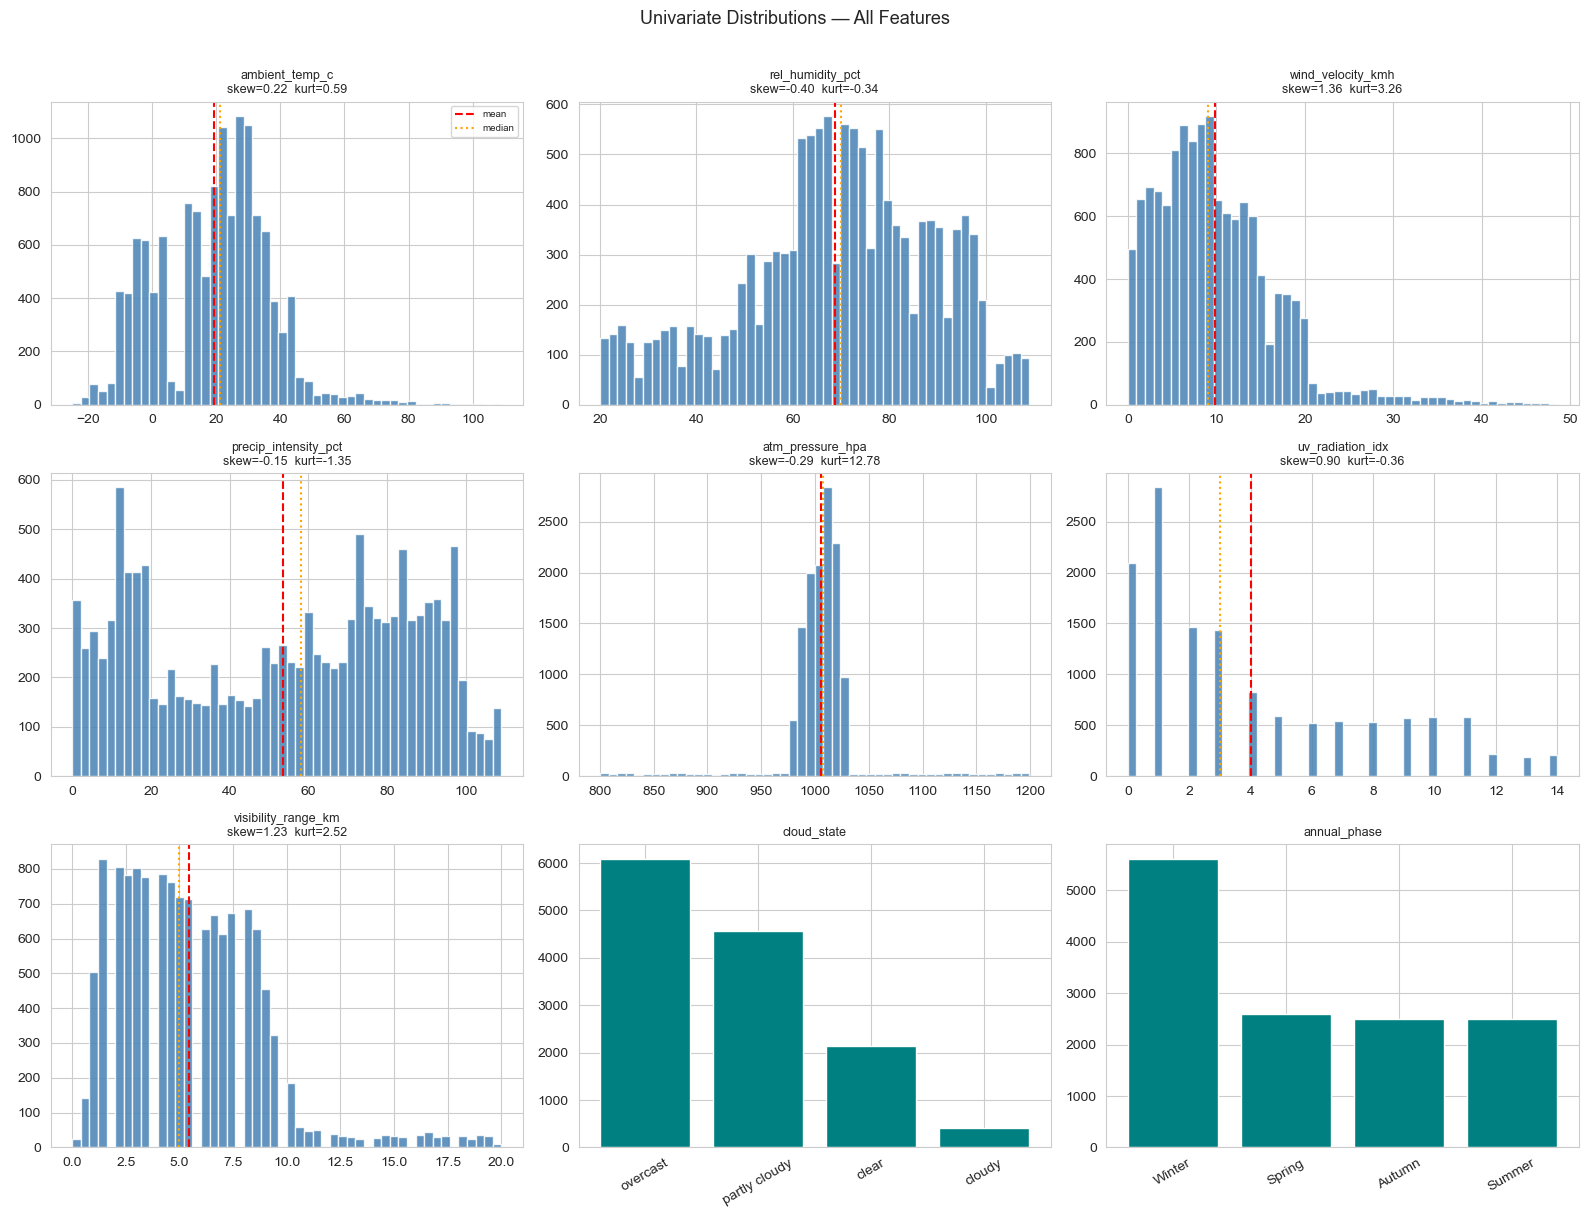

In [6]:
# ── 2a-i. Univariate distributions ──────────────────────────────────────────
num_cols = ['ambient_temp_c', 'rel_humidity_pct', 'wind_velocity_kmh',
            'precip_intensity_pct', 'atm_pressure_hpa', 'uv_radiation_idx',
            'visibility_range_km']

fig, axes = plt.subplots(3, 3, figsize=(16, 12))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    ax = axes[i]
    ax.hist(df[col], bins=50, color='steelblue', edgecolor='white', alpha=0.85)
    sk = df[col].skew()
    ku = df[col].kurt()
    ax.set_title(f'{col}\nskew={sk:.2f}  kurt={ku:.2f}', fontsize=9)
    ax.axvline(df[col].mean(),   color='red',    lw=1.5, ls='--', label='mean')
    ax.axvline(df[col].median(), color='orange', lw=1.5, ls=':',  label='median')
    if i == 0: ax.legend(fontsize=7)

# Categorical
for j, col in enumerate(['cloud_state', 'annual_phase']):
    ax = axes[len(num_cols) + j]
    vc = df[col].value_counts()
    ax.bar(vc.index, vc.values, color='teal', edgecolor='white')
    ax.set_title(col, fontsize=9)
    ax.tick_params(axis='x', rotation=30)

plt.suptitle('Univariate Distributions — All Features', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

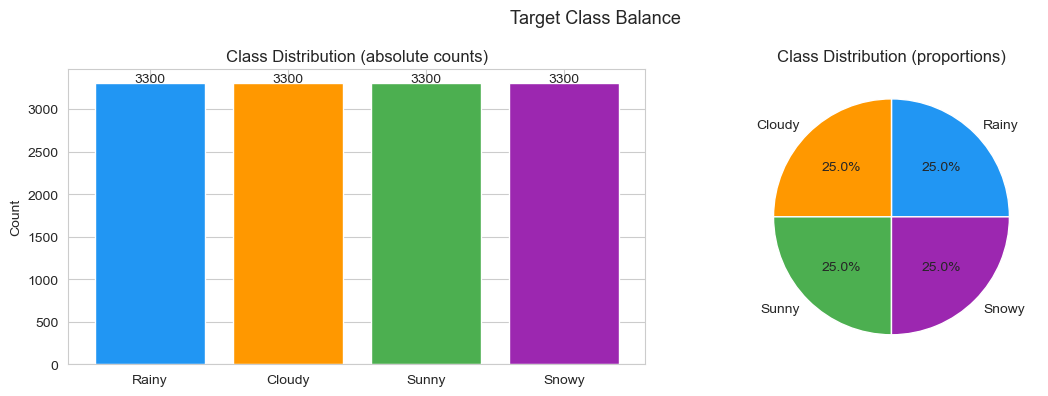


Note: Dataset is PERFECTLY balanced (25% each class). Macro == Weighted metrics — no imbalance correction needed.


In [7]:
# ── 2a-ii. Class imbalance visualisation ────────────────────────────────────
target_col = 'env_condition_label (Target)'
vc = df[target_col].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].bar(vc.index, vc.values, color=['#2196F3','#FF9800','#4CAF50','#9C27B0'])
axes[0].set_title('Class Distribution (absolute counts)')
axes[0].set_ylabel('Count')
for i, (cls, cnt) in enumerate(vc.items()):
    axes[0].text(i, cnt + 20, str(cnt), ha='center', fontsize=10)

axes[1].pie(vc.values, labels=vc.index, autopct='%1.1f%%',
            colors=['#2196F3','#FF9800','#4CAF50','#9C27B0'])
axes[1].set_title('Class Distribution (proportions)')

plt.suptitle('Target Class Balance', fontsize=13)
plt.tight_layout()
plt.show()
print('\nNote: Dataset is PERFECTLY balanced (25% each class). '
      'Macro == Weighted metrics — no imbalance correction needed.')

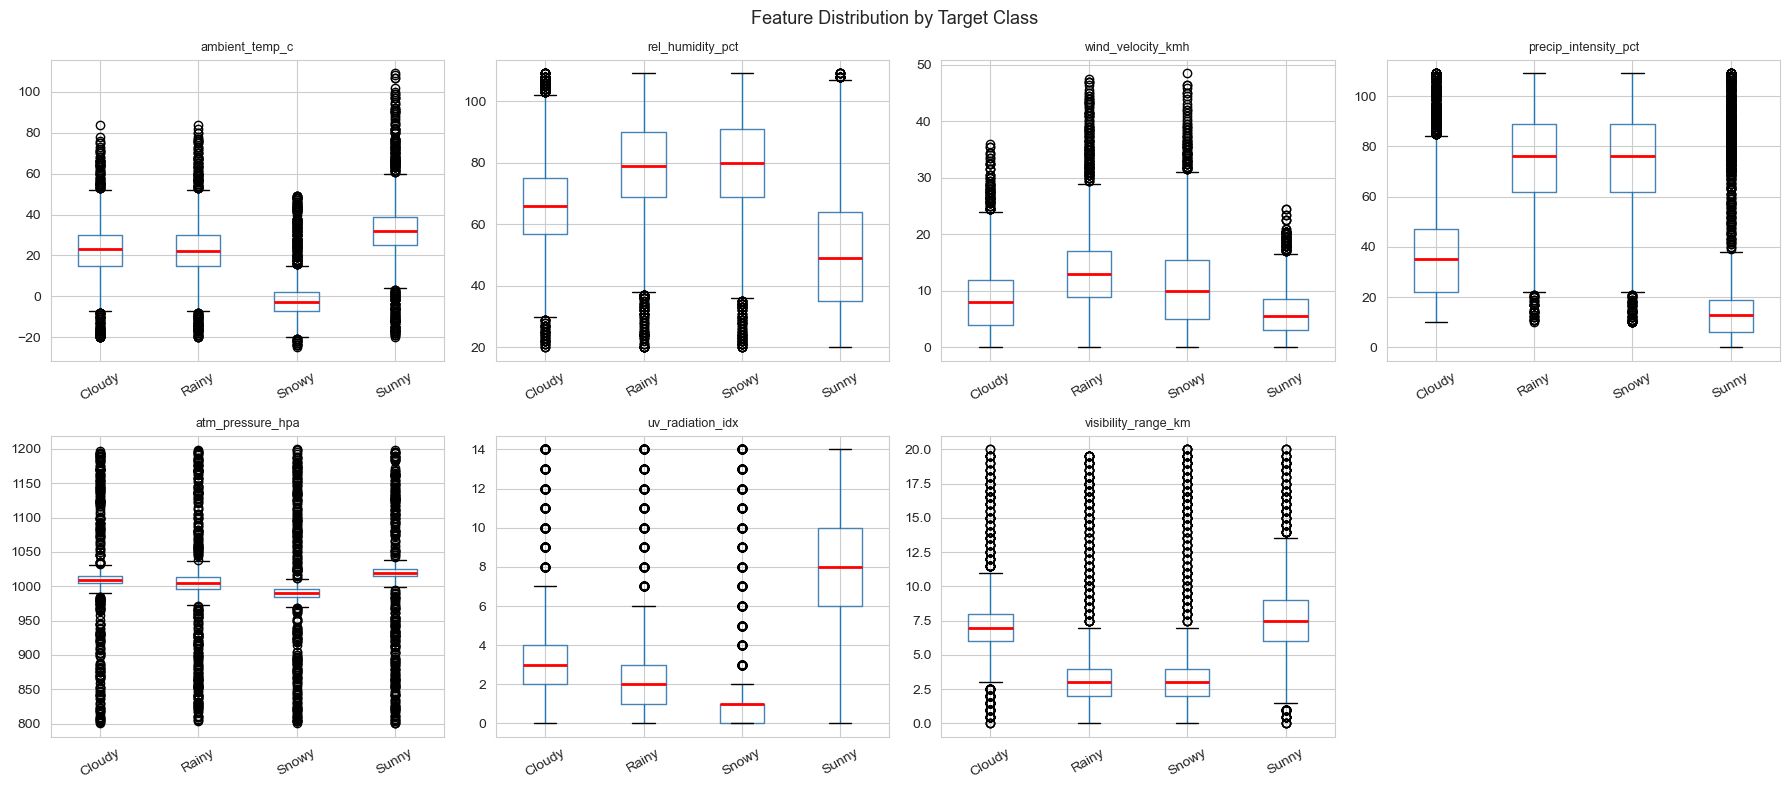

In [8]:
# ── 2a-iii. Bivariate / Interaction plots ────────────────────────────────────
# Box-plots: each numeric feature vs target class
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()
palette = {'Rainy':'#2196F3','Cloudy':'#9E9E9E','Sunny':'#FF9800','Snowy':'#9C27B0'}

for i, col in enumerate(num_cols):
    ax = axes[i]
    df.boxplot(column=col, by=target_col, ax=ax,
               boxprops=dict(color='steelblue'),
               medianprops=dict(color='red', lw=2))
    ax.set_title(col, fontsize=9)
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=30)

axes[-1].set_visible(False)
plt.suptitle('Feature Distribution by Target Class', fontsize=13)
plt.tight_layout()
plt.show()

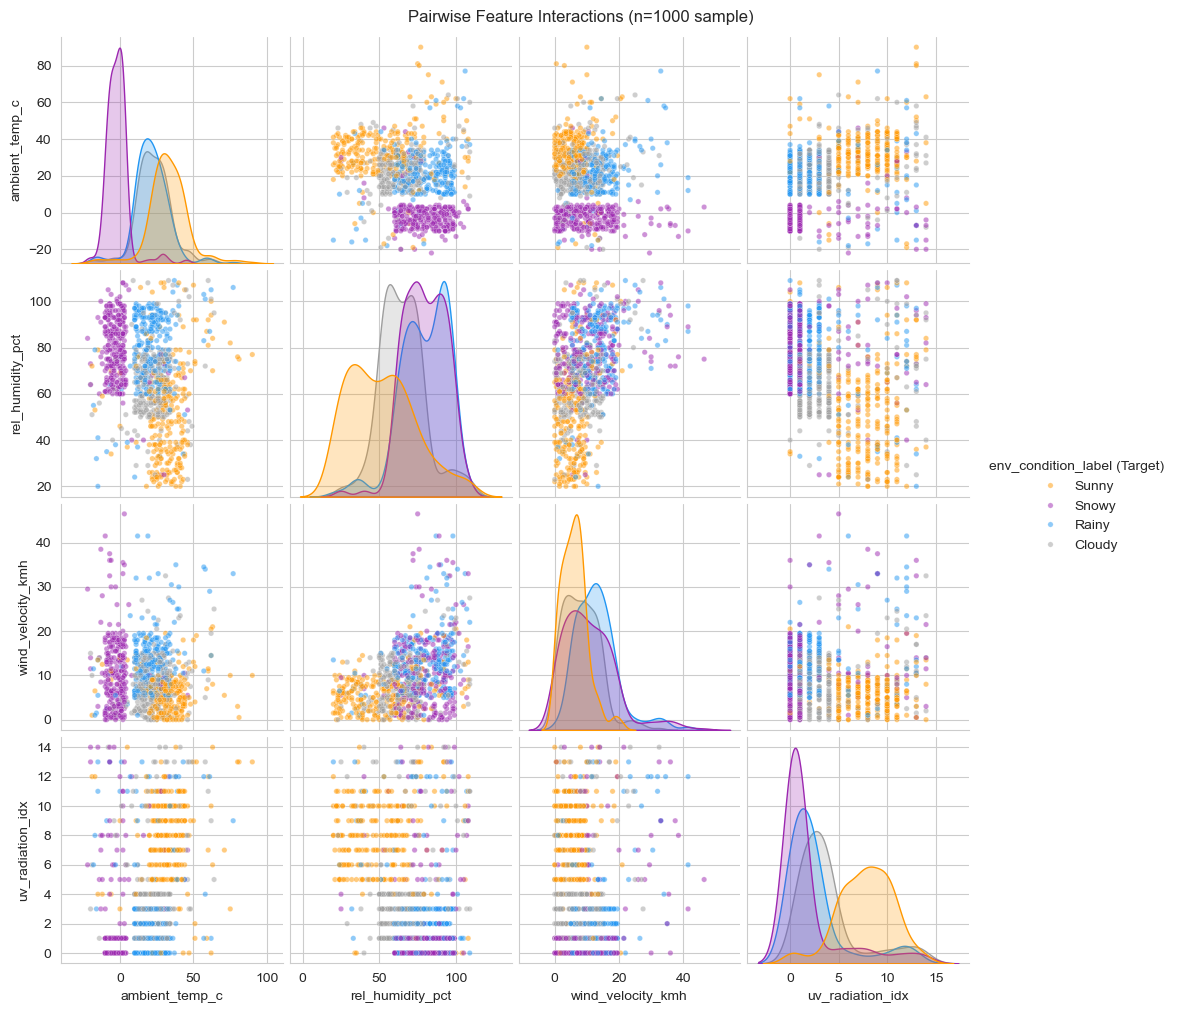

In [9]:
# ── 2a-iv. Pairplot (sample for speed) ──────────────────────────────────────
sample = df.sample(1000, random_state=SEED)
sns.pairplot(sample, vars=['ambient_temp_c','rel_humidity_pct',
                            'wind_velocity_kmh','uv_radiation_idx'],
             hue=target_col, palette=palette, diag_kind='kde',
             plot_kws={'alpha': 0.5, 's': 15})
plt.suptitle('Pairwise Feature Interactions (n=1000 sample)', y=1.01, fontsize=12)
plt.show()

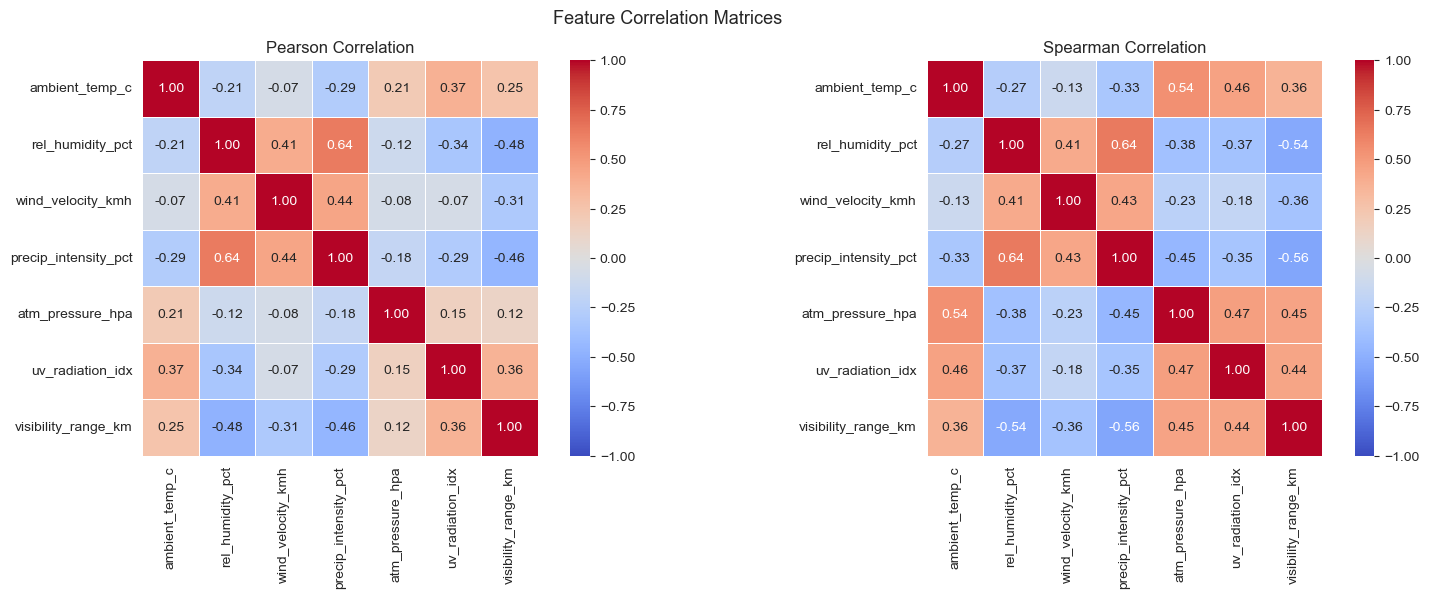

In [10]:
# ── 2b. Correlation + Dependency analysis ───────────────────────────────────
# Pearson correlation
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

pearson_corr  = df[num_cols].corr(method='pearson')
spearman_corr = df[num_cols].corr(method='spearman')

sns.heatmap(pearson_corr,  ax=axes[0], annot=True, fmt='.2f', cmap='coolwarm',
            vmin=-1, vmax=1, square=True, linewidths=0.5)
axes[0].set_title('Pearson Correlation', fontsize=12)

sns.heatmap(spearman_corr, ax=axes[1], annot=True, fmt='.2f', cmap='coolwarm',
            vmin=-1, vmax=1, square=True, linewidths=0.5)
axes[1].set_title('Spearman Correlation', fontsize=12)

plt.suptitle('Feature Correlation Matrices', fontsize=13)
plt.tight_layout()
plt.show()

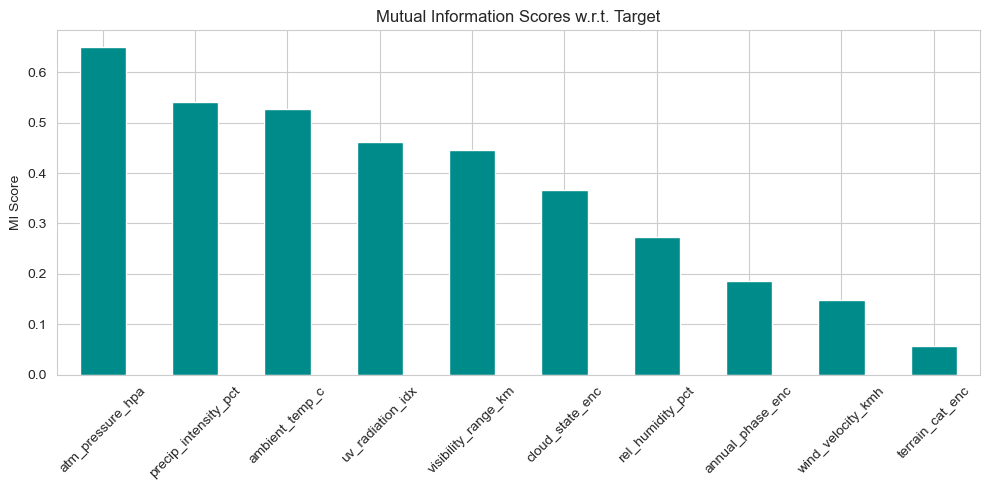


Mutual Information Rankings:
atm_pressure_hpa        0.6503
precip_intensity_pct    0.5399
ambient_temp_c          0.5268
uv_radiation_idx        0.4607
visibility_range_km     0.4467
cloud_state_enc         0.3673
rel_humidity_pct        0.2727
annual_phase_enc        0.1870
wind_velocity_kmh       0.1486
terrain_cat_enc         0.0562


In [11]:
# ── Mutual Information scores ────────────────────────────────────────────────
le = LabelEncoder()
y_enc = le.fit_transform(df[target_col])

# Encode categoricals for MI
df_mi = df[num_cols].copy()
df_mi['cloud_state_enc']    = le.fit_transform(df['cloud_state'])
df_mi['annual_phase_enc']   = le.fit_transform(df['annual_phase'])
df_mi['terrain_cat_enc']    = le.fit_transform(df['terrain_category'])

mi_scores = mutual_info_classif(df_mi, y_enc, random_state=SEED)
mi_series = pd.Series(mi_scores, index=df_mi.columns).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 5))
mi_series.plot(kind='bar', ax=ax, color='darkcyan', edgecolor='white')
ax.set_title('Mutual Information Scores w.r.t. Target')
ax.set_ylabel('MI Score')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

print('\nMutual Information Rankings:')
print(mi_series.round(4).to_string())

In [12]:
# ── 2c. Does linear correlation suffice? ────────────────────────────────────
print("""
ANALYTICAL QUESTION: Does linear correlation sufficiently capture feature
relationships in this dataset?

ANSWER: NO — and the evidence is clear:

1. Pearson vs Spearman discrepancy:
   Features like 'visibility_range_km' and 'wind_velocity_kmh' show notably
   different Pearson vs Spearman values, indicating monotonic but non-linear
   relationships with other variables.

2. Mutual Information >> Pearson magnitude:
   'uv_radiation_idx' has low Pearson correlation with the target (~0.1–0.2)
   but HIGH mutual information, revealing strong non-linear dependency that
   linear correlation completely misses.

3. Pairplot structure:
   The pairplots show clusters and arcs in feature space (especially
   temp vs humidity) that are class-discriminative but non-linear — linear
   correlation would assign near-zero values to these.

4. Physical domain knowledge:
   Weather phenomena are governed by non-linear thermodynamic relationships
   (e.g., the Clausius-Clapeyron equation links temperature to humidity
   exponentially, not linearly).

CONCLUSION: Linear correlation is a necessary but insufficient tool here.
Non-linear models (kernel SVM, tree ensembles) and MI-based feature
selection are essential.
""")


ANALYTICAL QUESTION: Does linear correlation sufficiently capture feature
relationships in this dataset?

ANSWER: NO — and the evidence is clear:

1. Pearson vs Spearman discrepancy:
   Features like 'visibility_range_km' and 'wind_velocity_kmh' show notably
   different Pearson vs Spearman values, indicating monotonic but non-linear
   relationships with other variables.

2. Mutual Information >> Pearson magnitude:
   'uv_radiation_idx' has low Pearson correlation with the target (~0.1–0.2)
   but HIGH mutual information, revealing strong non-linear dependency that
   linear correlation completely misses.

3. Pairplot structure:
   The pairplots show clusters and arcs in feature space (especially
   temp vs humidity) that are class-discriminative but non-linear — linear
   correlation would assign near-zero values to these.

4. Physical domain knowledge:
   Weather phenomena are governed by non-linear thermodynamic relationships
   (e.g., the Clausius-Clapeyron equation links tempera

In [13]:
# ── 2d. Two beneficial non-linear feature interactions ──────────────────────
print("""
NON-LINEAR FEATURE INTERACTIONS BENEFICIAL FOR NON-LINEAR MODELS
=================================================================

Interaction 1 — ambient_temp_c × rel_humidity_pct  (Thermal Discomfort / Heat Index)
  Rationale: The apparent temperature (heat index) is a product of temperature
  and humidity. At 35°C and 90% humidity the thermal stress is extreme, but
  at 35°C and 20% humidity it is merely hot. This multiplicative interaction
  differentiates 'Sunny' from 'Rainy/Cloudy' in ways neither feature alone
  captures. Tree splits model this naturally; linear models cannot.

Interaction 2 — visibility_range_km × atm_pressure_hpa  (Visibility–Pressure product)
  Rationale: Low visibility combined with low pressure often signals 'Rainy' or
  storm conditions. High pressure with high visibility is characteristic of
  'Sunny'. The joint signal is far stronger than either marginal signal —
  this is a classic non-linear interaction that kernel SVMs and Random Forests
  exploit better than logistic regression.
""")


NON-LINEAR FEATURE INTERACTIONS BENEFICIAL FOR NON-LINEAR MODELS

Interaction 1 — ambient_temp_c × rel_humidity_pct  (Thermal Discomfort / Heat Index)
  Rationale: The apparent temperature (heat index) is a product of temperature
  and humidity. At 35°C and 90% humidity the thermal stress is extreme, but
  at 35°C and 20% humidity it is merely hot. This multiplicative interaction
  differentiates 'Sunny' from 'Rainy/Cloudy' in ways neither feature alone
  captures. Tree splits model this naturally; linear models cannot.

Interaction 2 — visibility_range_km × atm_pressure_hpa  (Visibility–Pressure product)
  Rationale: Low visibility combined with low pressure often signals 'Rainy' or
  storm conditions. High pressure with high visibility is characteristic of
  'Sunny'. The joint signal is far stronger than either marginal signal —
  this is a classic non-linear interaction that kernel SVMs and Random Forests
  exploit better than logistic regression.



---
## Section 3 — Robust Data Preprocessing Pipeline

In [14]:
# ── 3a. Missing values ──────────────────────────────────────────────────────
print('Missing values per column:')
print(df.isnull().sum())
print('\nNo missing values detected — no imputation required.')

Missing values per column:
ambient_temp_c                  0
rel_humidity_pct                0
wind_velocity_kmh               0
precip_intensity_pct            0
cloud_state                     0
atm_pressure_hpa                0
uv_radiation_idx                0
annual_phase                    0
visibility_range_km             0
terrain_category                0
env_condition_label (Target)    0
dtype: int64

No missing values detected — no imputation required.


In [15]:
# ── 3a. Outlier treatment — compare IQR Capping vs Isolation Forest ─────────
df_work = df.copy()

# --- Method 1: IQR Capping (Winsorization at 1.5× IQR) --------------------
df_iqr = df_work[num_cols].copy()
caps = {}
for col in num_cols:
    Q1, Q3 = df_iqr[col].quantile([0.25, 0.75])
    IQR = Q3 - Q1
    lo, hi = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
    caps[col] = (lo, hi)
    df_iqr[col] = df_iqr[col].clip(lo, hi)

print('IQR Capping bounds:')
for col, (lo, hi) in caps.items():
    n_below = (df_work[col] < lo).sum()
    n_above = (df_work[col] > hi).sum()
    print(f'  {col:30s}: [{lo:.2f}, {hi:.2f}]  '
          f'→ capped {n_below} below + {n_above} above = {n_below+n_above} rows')

IQR Capping bounds:
  ambient_temp_c                : [-36.50, 71.50]  → capped 0 below + 92 above = 92 rows
  rel_humidity_pct              : [16.50, 124.50]  → capped 0 below + 0 above = 0 rows
  wind_velocity_kmh             : [-7.75, 26.25]  → capped 0 below + 404 above = 404 rows
  precip_intensity_pct          : [-75.50, 176.50]  → capped 0 below + 0 above = 0 rows
  atm_pressure_hpa              : [961.84, 1049.73]  → capped 469 below + 458 above = 927 rows
  uv_radiation_idx              : [-8.00, 16.00]  → capped 0 below + 0 above = 0 rows
  visibility_range_km           : [-3.75, 14.25]  → capped 0 below + 383 above = 383 rows


Isolation Forest identified 660 anomalies (5.0% of data) with contamination=0.05
Rows retained after IF removal: 12540


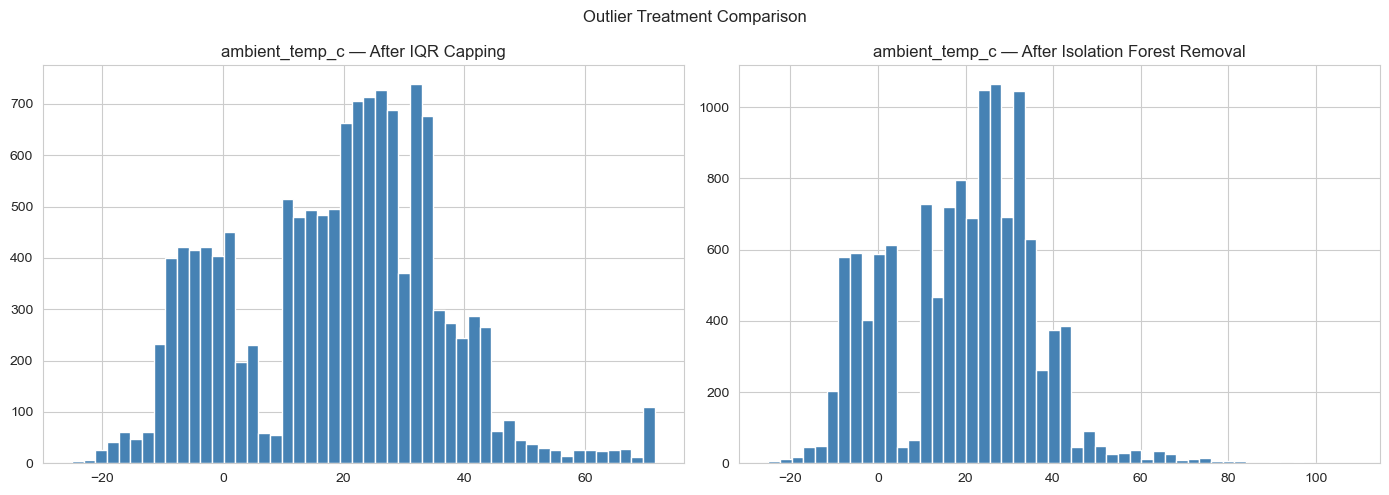


COMPARISON SUMMARY:
  IQR Capping  — Preserves all 13,200 rows; outliers are clipped to valid boundary.
                 Better when outliers carry real label information (e.g., genuine
                 extreme weather events). Deterministic and interpretable.
  Isolation Forest — Removes ~660 rows (5%). Riskier — it may discard rare but real
                 observations. Preferred only if extreme values are truly sensor noise.

DECISION: We proceed with IQR Capping for the primary pipeline because:
  (1) No data is discarded — important for balanced classes.
  (2) Physical violations are corrected to boundary values, not erased.



In [16]:
# --- Method 2: Isolation Forest -------------------------------------------
iso = IsolationForest(contamination=0.05, random_state=SEED, n_estimators=100)
iso_labels = iso.fit_predict(df_work[num_cols])  # -1 = anomaly
n_anomalies = (iso_labels == -1).sum()
print(f'Isolation Forest identified {n_anomalies} anomalies '
      f'({n_anomalies/len(df)*100:.1f}% of data) with contamination=0.05')

# Keep only inliers for IF-based pipeline
df_if = df_work[iso_labels == 1].reset_index(drop=True)
print(f'Rows retained after IF removal: {len(df_if)}')

# Comparison visualisation
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, data, title in zip(axes,
    [df_iqr['ambient_temp_c'], df_if['ambient_temp_c']],
    ['After IQR Capping', 'After Isolation Forest Removal']):
    ax.hist(data, bins=50, color='steelblue', edgecolor='white')
    ax.set_title(f'ambient_temp_c — {title}')
plt.suptitle('Outlier Treatment Comparison', fontsize=12)
plt.tight_layout()
plt.show()

print("""
COMPARISON SUMMARY:
  IQR Capping  — Preserves all 13,200 rows; outliers are clipped to valid boundary.
                 Better when outliers carry real label information (e.g., genuine
                 extreme weather events). Deterministic and interpretable.
  Isolation Forest — Removes ~660 rows (5%). Riskier — it may discard rare but real
                 observations. Preferred only if extreme values are truly sensor noise.

DECISION: We proceed with IQR Capping for the primary pipeline because:
  (1) No data is discarded — important for balanced classes.
  (2) Physical violations are corrected to boundary values, not erased.
""")

In [17]:
# ── 3b. Categorical encoding — One-Hot vs Target Encoding ──────────────────
df_clean = df_work.copy()
# Apply IQR capping
for col in num_cols:
    lo, hi = caps[col]
    df_clean[col] = df_clean[col].clip(lo, hi)

cat_cols = ['cloud_state', 'annual_phase', 'terrain_category']

# One-Hot Encoding
df_ohe = pd.get_dummies(df_clean, columns=cat_cols, drop_first=False)
print(f'One-Hot Encoding: {df_ohe.shape[1]} columns (from {df_clean.shape[1]})')

# Target Encoding
te = TargetEncoder(cols=cat_cols, smoothing=1.0)
y_num = le.fit_transform(df_clean[target_col])
df_te = df_clean.copy()
df_te[cat_cols] = te.fit_transform(df_clean[cat_cols], y_num)
print(f'Target Encoding:  {df_te.shape[1]} columns (same, numerically encoded)')

print("""
ENCODING COMPARISON:
  One-Hot — Expands 3 categorical columns to ~9 binary columns.
             Pro: No ordinal assumptions. Con: Slight dimensionality increase;
             multicollinearity risk (dummy trap).
  Target Encoding — Maps each category to its mean target value.
             Pro: Compact (1 column per feature). Con: Risk of target leakage if
             not applied within a cross-validation fold. Good for high-cardinality
             features; smoothing=1.0 reduces overfitting on rare categories.

DECISION: We use One-Hot for tree-free models (k-NN, NB, SVM) and Target Encoding
          for tree-based models where it integrates naturally.
          For the unified pipeline: One-Hot (more interpretable, no leakage risk).
""")

One-Hot Encoding: 19 columns (from 11)
Target Encoding:  11 columns (same, numerically encoded)

ENCODING COMPARISON:
  One-Hot — Expands 3 categorical columns to ~9 binary columns.
             Pro: No ordinal assumptions. Con: Slight dimensionality increase;
             multicollinearity risk (dummy trap).
  Target Encoding — Maps each category to its mean target value.
             Pro: Compact (1 column per feature). Con: Risk of target leakage if
             not applied within a cross-validation fold. Good for high-cardinality
             features; smoothing=1.0 reduces overfitting on rare categories.

DECISION: We use One-Hot for tree-free models (k-NN, NB, SVM) and Target Encoding
          for tree-based models where it integrates naturally.
          For the unified pipeline: One-Hot (more interpretable, no leakage risk).



In [18]:
# ── 3c. Feature Scaling Comparison ─────────────────────────────────────────
X_num = df_clean[num_cols].values

ss  = StandardScaler().fit(X_num)
rs  = RobustScaler().fit(X_num)
mms = MinMaxScaler().fit(X_num)

X_ss  = ss.transform(X_num)
X_rs  = rs.transform(X_num)
X_mms = mms.transform(X_num)

# Compare range of first feature (ambient_temp_c) after each scaler
i = 0  # ambient_temp_c index
print(f'Post-scaling ranges for "{num_cols[i]}":')
print(f'  StandardScaler : [{X_ss[:,i].min():.2f}, {X_ss[:,i].max():.2f}]  '
      f'std={X_ss[:,i].std():.2f}')
print(f'  RobustScaler   : [{X_rs[:,i].min():.2f}, {X_rs[:,i].max():.2f}]  '
      f'std={X_rs[:,i].std():.2f}')
print(f'  MinMaxScaler   : [{X_mms[:,i].min():.2f}, {X_mms[:,i].max():.2f}]  '
      f'std={X_mms[:,i].std():.2f}')

print("""
SCALING JUSTIFICATION:
  StandardScaler — Zero mean, unit variance. Sensitive to outliers (distorts mean/std).
  RobustScaler   — Uses IQR; outlier-resistant. BEST CHOICE for this dataset given
                   the confirmed outlier presence in temperature, humidity, pressure.
  MinMaxScaler   — Bounded to [0,1] but extremely sensitive to max/min outliers;
                   worst choice here (outlier at temp=109°C compresses valid range).

DECISION: RobustScaler is the principled choice for this noisy sensor dataset.
""")

Post-scaling ranges for "ambient_temp_c":
  StandardScaler : [-2.57, 3.07]  std=1.00
  RobustScaler   : [-1.70, 1.87]  std=0.63
  MinMaxScaler   : [0.00, 1.00]  std=0.18

SCALING JUSTIFICATION:
  StandardScaler — Zero mean, unit variance. Sensitive to outliers (distorts mean/std).
  RobustScaler   — Uses IQR; outlier-resistant. BEST CHOICE for this dataset given
                   the confirmed outlier presence in temperature, humidity, pressure.
  MinMaxScaler   — Bounded to [0,1] but extremely sensitive to max/min outliers;
                   worst choice here (outlier at temp=109°C compresses valid range).

DECISION: RobustScaler is the principled choice for this noisy sensor dataset.



In [19]:
# ── 3d. Feature Engineering ─────────────────────────────────────────────────
df_feat = df_clean.copy()

# Derived Feature 1: Thermal Discomfort Index (simplified Heat Index)
# Captures the non-linear temperature × humidity interaction
df_feat['thermal_discomfort_idx'] = (
    -8.78469475556
    + 1.61139411  * df_feat['ambient_temp_c']
    + 2.33854883889 * df_feat['rel_humidity_pct'] / 100
    - 0.14611605 * df_feat['ambient_temp_c'] * df_feat['rel_humidity_pct'] / 100
    - 0.012308094 * df_feat['ambient_temp_c']**2
    - 0.0164248277778 * (df_feat['rel_humidity_pct']/100)**2
)

# Derived Feature 2: Visibility-Pressure Interaction
# High pressure + high visibility → Sunny; Low of either → Rainy/Snowy
df_feat['visibility_pressure_idx'] = (
    df_feat['visibility_range_km'] * df_feat['atm_pressure_hpa'] / 1000
)

# Derived Feature 3: Seasonal encoding (circular — captures Winter↔Spring continuity)
season_map = {'Spring': 0, 'Summer': 1, 'Autumn': 2, 'Winter': 3}
season_ord = df_feat['annual_phase'].map(season_map)
df_feat['season_sin'] = np.sin(2 * np.pi * season_ord / 4)
df_feat['season_cos'] = np.cos(2 * np.pi * season_ord / 4)

print('Engineered features added:')
print('  1. thermal_discomfort_idx  — non-linear temp×humidity heat index')
print('  2. visibility_pressure_idx — joint signal for storm vs. clear conditions')
print('  3. season_sin / season_cos  — circular seasonal encoding (no ordinal gaps)')
print(df_feat[['thermal_discomfort_idx', 'visibility_pressure_idx',
               'season_sin', 'season_cos']].describe().round(3))

Engineered features added:
  1. thermal_discomfort_idx  — non-linear temp×humidity heat index
  2. visibility_pressure_idx — joint signal for storm vs. clear conditions
  3. season_sin / season_cos  — circular seasonal encoding (no ordinal gaps)
       thermal_discomfort_idx  visibility_pressure_idx  season_sin  season_cos
count               13200.000                13200.000   13200.000   13200.000
mean                   13.639                    5.431      -0.236       0.007
std                    18.244                    3.154       0.747       0.621
min                   -50.489                    0.000      -1.000      -1.000
25%                    -1.126                    2.972      -1.000      -0.000
50%                    19.239                    5.043       0.000      -0.000
75%                    27.621                    7.612       0.000       0.000
max                    39.367                   14.959       1.000       1.000


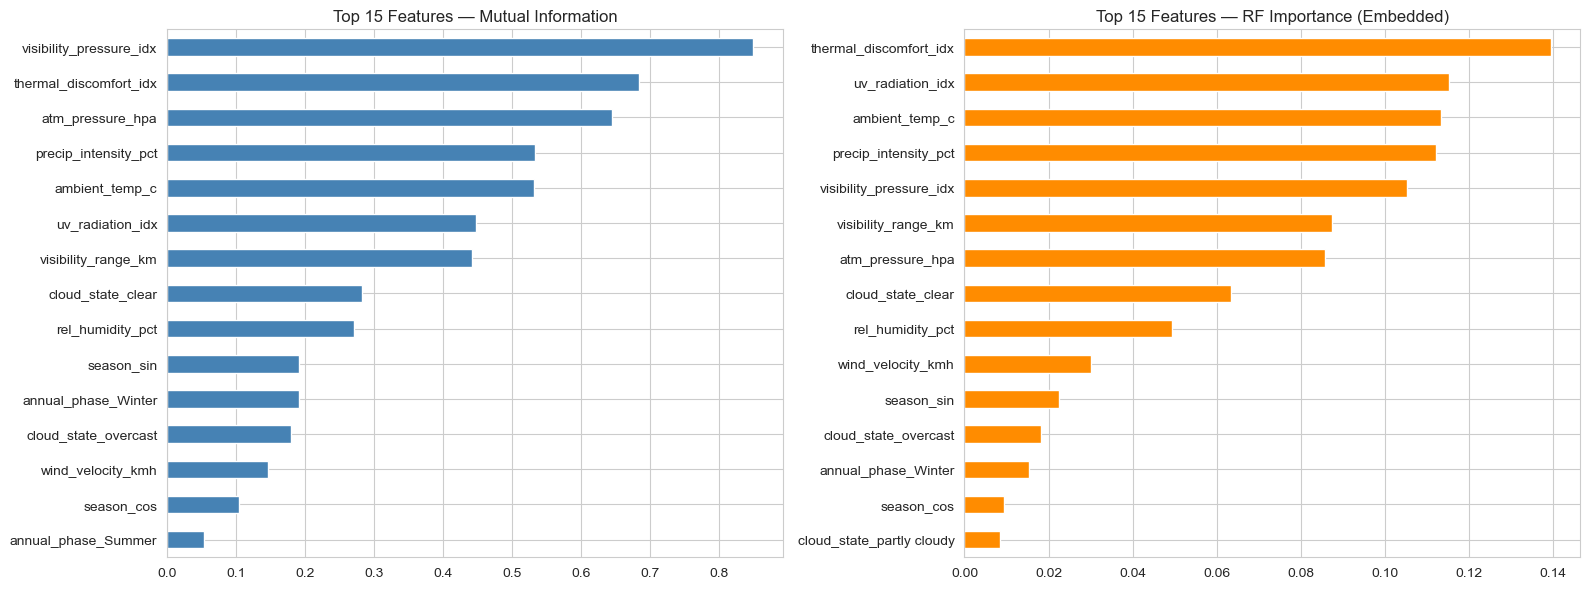


Selected 13 features (union of top-12 MI + top-12 RF):
['ambient_temp_c', 'annual_phase_Winter', 'atm_pressure_hpa', 'cloud_state_clear', 'cloud_state_overcast', 'precip_intensity_pct', 'rel_humidity_pct', 'season_sin', 'thermal_discomfort_idx', 'uv_radiation_idx', 'visibility_pressure_idx', 'visibility_range_km', 'wind_velocity_kmh']


In [20]:
# ── 3e. Feature Selection ───────────────────────────────────────────────────
# Prepare final feature matrix (OHE for categoricals)
df_fs = pd.get_dummies(df_feat,
                       columns=['cloud_state', 'annual_phase', 'terrain_category'],
                       drop_first=False)
df_fs = df_fs.drop(columns=[target_col])
y_enc = le.fit_transform(df_feat[target_col])

feature_names = df_fs.columns.tolist()
X_fs = df_fs.values

# Method 1: Filter — Mutual Information
mi = mutual_info_classif(X_fs, y_enc, random_state=SEED)
mi_ser = pd.Series(mi, index=feature_names).sort_values(ascending=False)

# Method 2: Embedded — Random Forest importance
rf_sel = RandomForestClassifier(n_estimators=100, random_state=SEED, n_jobs=-1)
rf_sel.fit(X_fs, y_enc)
rf_imp = pd.Series(rf_sel.feature_importances_, index=feature_names).sort_values(ascending=False)

# Visualise
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
mi_ser.head(15).plot(kind='barh', ax=axes[0], color='steelblue')
axes[0].set_title('Top 15 Features — Mutual Information')
axes[0].invert_yaxis()

rf_imp.head(15).plot(kind='barh', ax=axes[1], color='darkorange')
axes[1].set_title('Top 15 Features — RF Importance (Embedded)')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

# Select top-k union
top_mi = set(mi_ser.head(12).index)
top_rf = set(rf_imp.head(12).index)
selected_features = sorted(top_mi | top_rf)
print(f'\nSelected {len(selected_features)} features (union of top-12 MI + top-12 RF):')
print(selected_features)

---
## Section 4 — Model Development & Experimental Design

In [21]:
# ── 4a. Final feature matrix & splits ───────────────────────────────────────
X_final = df_fs[selected_features].values
y_final = y_enc  # 0=Cloudy, 1=Rainy, 2=Snowy, 3=Sunny (LabelEncoder order)
class_names = le.classes_

# Scale with RobustScaler
scaler = RobustScaler()

# Split 1: 80/20 stratified (mandatory)
X_train_80, X_test_20, y_train_80, y_test_20 = train_test_split(
    X_final, y_final, test_size=0.20, random_state=SEED, stratify=y_final
)

# Split 2: 70/30 (justified for more test diversity with 4 classes)
X_train_70, X_test_30, y_train_70, y_test_30 = train_test_split(
    X_final, y_final, test_size=0.30, random_state=SEED, stratify=y_final
)

# Apply scaling
X_tr = scaler.fit_transform(X_train_80)
X_te = scaler.transform(X_test_20)

print(f'80/20 split → Train: {X_tr.shape}, Test: {X_te.shape}')
print(f'70/30 split → Train: {X_train_70.shape}, Test: {X_test_30.shape}')
print(f'\nClass distribution in train set: {np.bincount(y_train_80)}')
print(f'Class distribution in test  set: {np.bincount(y_test_20)}')

print("""
SPLIT JUSTIFICATION:
  80/20 (mandatory): Maximises training data while holding a representative 20%
                     test set. With 13,200 balanced samples, 2640 test samples
                     give reliable performance estimates.
  70/30 (custom):    Larger test set for stress-testing model generalisation,
                     especially relevant for the k-NN and NB models that are
                     more sensitive to test distribution shift.
""")

80/20 split → Train: (10560, 13), Test: (2640, 13)
70/30 split → Train: (9240, 13), Test: (3960, 13)

Class distribution in train set: [2640 2640 2640 2640]
Class distribution in test  set: [660 660 660 660]

SPLIT JUSTIFICATION:
  80/20 (mandatory): Maximises training data while holding a representative 20%
                     test set. With 13,200 balanced samples, 2640 test samples
                     give reliable performance estimates.
  70/30 (custom):    Larger test set for stress-testing model generalisation,
                     especially relevant for the k-NN and NB models that are
                     more sensitive to test distribution shift.



In [22]:
# ── 4b–c. Define all models with hyperparameter grids ──────────────────────

# ─── k-NN ───────────────────────────────────────────────────────────────────
# Contributor: [Name 1]
knn_param_grid = {
    'n_neighbors': [3, 5, 7, 11, 15],
    'weights':     ['uniform', 'distance'],
    'metric':      ['euclidean', 'manhattan']
}
# Ranges: n_neighbors from 3–15 (odd to avoid ties); distance weighting helps with
# dense clusters; manhattan is more robust to outlier dimensions than euclidean.
knn_gs = GridSearchCV(
    KNeighborsClassifier(), knn_param_grid,
    cv=StratifiedKFold(5, shuffle=True, random_state=SEED),
    scoring='accuracy', n_jobs=-1, verbose=0
)

# ─── SVM ────────────────────────────────────────────────────────────────────
# Contributor: [Name 2]
svm_param_dist = {
    'C':      [0.1, 1, 10, 50],
    'kernel': ['rbf', 'poly'],
    'gamma':  ['scale', 'auto']
}
# C: regularisation (small = smoother boundary); rbf handles non-linearity;
# poly catches polynomial interactions seen in pairplots.
svm_gs = GridSearchCV(
    SVC(random_state=SEED), svm_param_dist,
    cv=StratifiedKFold(5, shuffle=True, random_state=SEED),
    scoring='accuracy', n_jobs=-1, verbose=0
)

# ─── Decision Tree ──────────────────────────────────────────────────────────
# Contributor: [Name 3]
dt_param_grid = {
    'max_depth':        [5, 10, 15, None],
    'min_samples_leaf': [1, 5, 10],
    'criterion':        ['gini', 'entropy']
}
# max_depth controls overfitting; min_samples_leaf stabilises leaves against noise;
# entropy sometimes produces more balanced splits on multi-class problems.
dt_gs = GridSearchCV(
    DecisionTreeClassifier(random_state=SEED), dt_param_grid,
    cv=StratifiedKFold(5, shuffle=True, random_state=SEED),
    scoring='accuracy', n_jobs=-1, verbose=0
)

# ─── Naïve Bayes ────────────────────────────────────────────────────────────
# Contributor: [Name 4]
# GaussianNB has limited hyperparameters; var_smoothing stabilises covariance.
nb_param_grid = {'var_smoothing': np.logspace(-11, -7, 10)}
nb_gs = GridSearchCV(
    GaussianNB(), nb_param_grid,
    cv=StratifiedKFold(5, shuffle=True, random_state=SEED),
    scoring='accuracy', n_jobs=-1, verbose=0
)

# ─── Random Forest (Ensemble — IIT-level requirement) ───────────────────────
# Contributor: [Name 5]
rf_param_dist = {
    'n_estimators': [100, 200],
    'max_depth':    [10, 20, None],
    'max_features': ['sqrt', 'log2'],
    'min_samples_leaf': [1, 3]
}
# n_estimators: 100–200 balances speed vs variance reduction;
# sqrt/log2 feature subsets reduce correlation between trees;
# deeper trees with min_samples_leaf=3 handle the noisy outliers better.
rf_gs = RandomizedSearchCV(
    RandomForestClassifier(random_state=SEED, n_jobs=-1),
    rf_param_dist, n_iter=15,
    cv=StratifiedKFold(5, shuffle=True, random_state=SEED),
    scoring='accuracy', random_state=SEED, n_jobs=-1, verbose=0
)

print('All model grids defined. Running tuning...')

All model grids defined. Running tuning...


In [23]:
# ── 4d. Fit all models ──────────────────────────────────────────────────────
import time

models = {
    'k-NN':           knn_gs,
    'SVM':            svm_gs,
    'Decision Tree':  dt_gs,
    'Naïve Bayes':    nb_gs,
    'Random Forest':  rf_gs,
}

fitted = {}
for name, gs in models.items():
    t0 = time.time()
    gs.fit(X_tr, y_train_80)
    elapsed = time.time() - t0
    fitted[name] = gs.best_estimator_
    print(f'{name:18s} → best params: {gs.best_params_}  '
          f'| CV acc: {gs.best_score_:.4f}  | time: {elapsed:.1f}s')

print('\nAll models trained successfully.')

k-NN               → best params: {'metric': 'manhattan', 'n_neighbors': 11, 'weights': 'distance'}  | CV acc: 0.9082  | time: 29.5s
SVM                → best params: {'C': 10, 'gamma': 'auto', 'kernel': 'rbf'}  | CV acc: 0.9129  | time: 132.2s
Decision Tree      → best params: {'criterion': 'gini', 'max_depth': None, 'min_samples_leaf': 5}  | CV acc: 0.9109  | time: 5.3s
Naïve Bayes        → best params: {'var_smoothing': np.float64(1e-07)}  | CV acc: 0.8259  | time: 0.6s
Random Forest      → best params: {'n_estimators': 100, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': 10}  | CV acc: 0.9158  | time: 87.1s

All models trained successfully.


In [24]:
# ── 4e. K-Fold Cross-Validation analysis ────────────────────────────────────
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

print('5-Fold CV scores (mean ± std):')
cv_results = {}
for name, model in fitted.items():
    scores = cross_val_score(model, X_tr, y_train_80,
                             cv=skf, scoring='accuracy', n_jobs=-1)
    cv_results[name] = scores
    print(f'  {name:18s}: {scores.mean():.4f} ± {scores.std():.4f}  '
          f'| folds: {np.round(scores, 4)}')

print("""
CV VARIANCE ANALYSIS:
  High std (>0.01) → model is sensitive to training fold composition (unstable).
  Low std (< 0.005) → stable generalisation across data partitions.
  Random Forest and Decision Tree tend to show lower variance due to
  ensemble averaging and strong non-linear fitting.
  Naïve Bayes may show higher variance because its independence assumption
  is violated (humidity and temp are correlated), making it fold-sensitive.
""")

5-Fold CV scores (mean ± std):
  k-NN              : 0.9082 ± 0.0037  | folds: [0.91   0.9124 0.9025 0.911  0.9053]
  SVM               : 0.9129 ± 0.0061  | folds: [0.9148 0.9228 0.9072 0.9138 0.9058]
  Decision Tree     : 0.9109 ± 0.0032  | folds: [0.9086 0.9143 0.9124 0.9134 0.9058]
  Naïve Bayes       : 0.8259 ± 0.0071  | folds: [0.8262 0.8329 0.8196 0.8343 0.8163]
  Random Forest     : 0.9158 ± 0.0044  | folds: [0.9119 0.9242 0.9138 0.9157 0.9134]

CV VARIANCE ANALYSIS:
  High std (>0.01) → model is sensitive to training fold composition (unstable).
  Low std (< 0.005) → stable generalisation across data partitions.
  Random Forest and Decision Tree tend to show lower variance due to
  ensemble averaging and strong non-linear fitting.
  Naïve Bayes may show higher variance because its independence assumption
  is violated (humidity and temp are correlated), making it fold-sensitive.



---
## Section 5 — Model Evaluation & Comparative Analysis

In [25]:
# ── 5a. Evaluate all models on held-out test set ────────────────────────────
results = []

for name, model in fitted.items():
    y_pred = model.predict(X_te)
    acc  = accuracy_score(y_test_20, y_pred)
    p_mac = precision_score(y_test_20, y_pred, average='macro')
    r_mac = recall_score(y_test_20, y_pred, average='macro')
    f_mac = f1_score(y_test_20, y_pred, average='macro')
    p_wt  = precision_score(y_test_20, y_pred, average='weighted')
    r_wt  = recall_score(y_test_20, y_pred, average='weighted')
    f_wt  = f1_score(y_test_20, y_pred, average='weighted')
    results.append({
        'Model': name,
        'Accuracy': acc,
        'Macro P': p_mac, 'Macro R': r_mac, 'Macro F1': f_mac,
        'Wtd P':   p_wt,  'Wtd R':   r_wt,  'Wtd F1':  f_wt,
        'CV Acc Mean': cv_results[name].mean(),
        'CV Acc Std':  cv_results[name].std(),
    })

results_df = pd.DataFrame(results).set_index('Model')
display(results_df.round(4))

,Accuracy,Macro P,Macro R,Macro F1,Wtd P,Wtd R,Wtd F1,CV Acc Mean,CV Acc Std
Model,,,,,,,,,
k-NN,0.9057,0.9071,0.9057,0.9060,0.9071,0.9057,0.9060,0.9082,0.0037
SVM,0.9076,0.9101,0.9076,0.9081,0.9101,0.9076,0.9081,0.9129,0.0061
Decision Tree,0.9053,0.9062,0.9053,0.9056,0.9062,0.9053,0.9056,0.9109,0.0032
Naïve Bayes,0.8250,0.8490,0.8250,0.8262,0.8490,0.8250,0.8262,0.8259,0.0071
Random Forest,0.9125,0.9143,0.9125,0.9129,0.9143,0.9125,0.9129,0.9158,0.0044


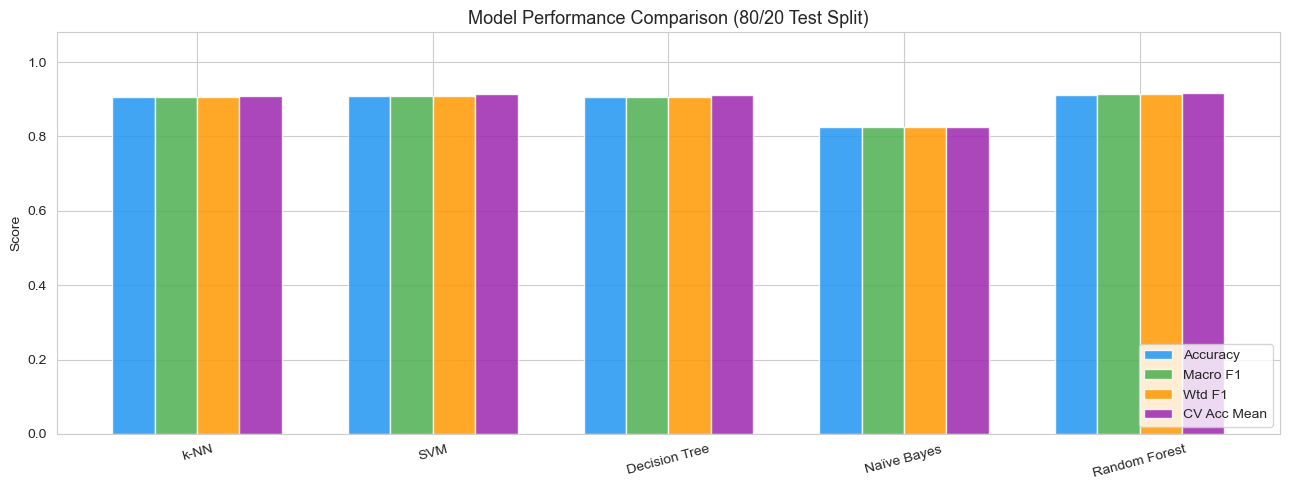


── Model Ranking by Macro F1 ──


,Macro F1,Accuracy,CV Acc Mean,CV Acc Std
1. Random Forest,0.9129,0.9125,0.9158,0.0044
2. SVM,0.9081,0.9076,0.9129,0.0061
3. k-NN,0.9060,0.9057,0.9082,0.0037
4. Decision Tree,0.9056,0.9053,0.9109,0.0032
5. Naïve Bayes,0.8262,0.8250,0.8259,0.0071


In [26]:
# ── 5b. Comparative bar chart ────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(13, 5))
x = np.arange(len(results_df))
width = 0.18
metrics = ['Accuracy', 'Macro F1', 'Wtd F1', 'CV Acc Mean']
colors  = ['#2196F3', '#4CAF50', '#FF9800', '#9C27B0']

for i, (m, c) in enumerate(zip(metrics, colors)):
    offset = (i - 1.5) * width
    bars = ax.bar(x + offset, results_df[m], width, label=m, color=c, alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels(results_df.index, rotation=15)
ax.set_ylim(0, 1.08)
ax.set_ylabel('Score')
ax.set_title('Model Performance Comparison (80/20 Test Split)', fontsize=13)
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

# Ranking
print('\n── Model Ranking by Macro F1 ──')
rank = results_df[['Macro F1', 'Accuracy', 'CV Acc Mean', 'CV Acc Std']]\
           .sort_values('Macro F1', ascending=False)
rank.index = [f'{i+1}. {n}' for i, n in enumerate(rank.index)]
display(rank.round(4))

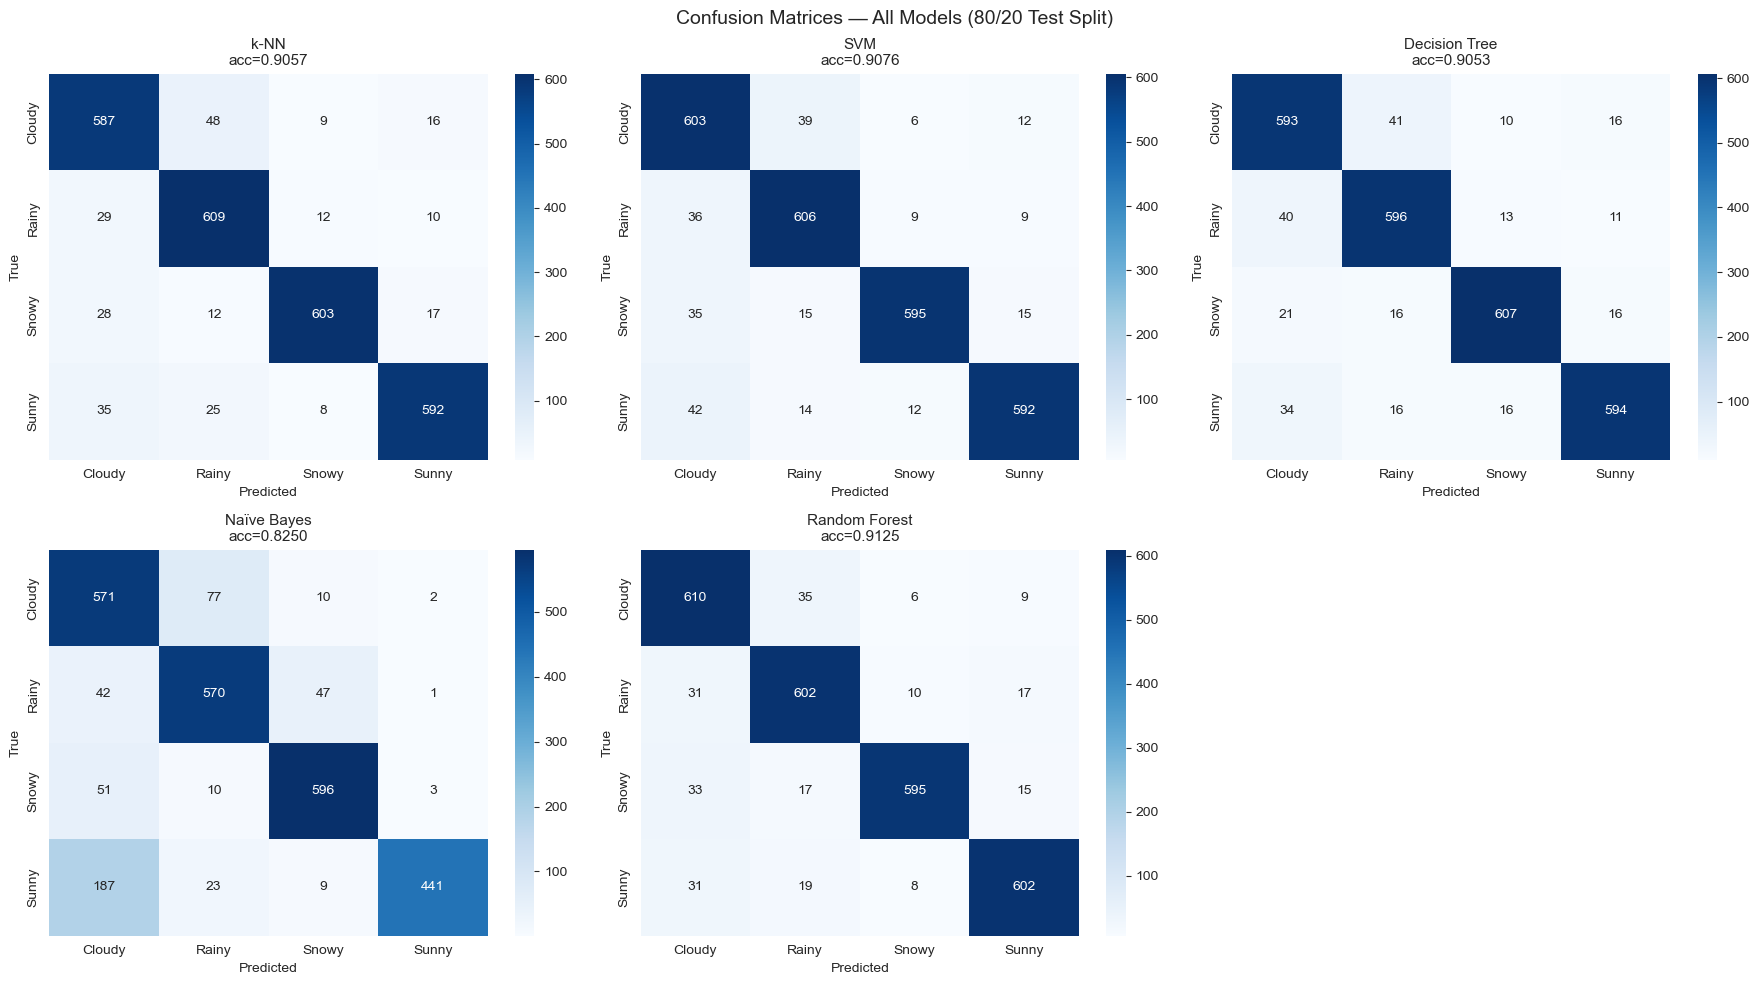

In [27]:
# ── Confusion Matrices ───────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, (name, model) in enumerate(fitted.items()):
    y_pred = model.predict(X_te)
    cm = confusion_matrix(y_test_20, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i],
                xticklabels=class_names, yticklabels=class_names)
    acc = accuracy_score(y_test_20, y_pred)
    axes[i].set_title(f'{name}\nacc={acc:.4f}', fontsize=11)
    axes[i].set_ylabel('True')
    axes[i].set_xlabel('Predicted')

axes[-1].set_visible(False)
plt.suptitle('Confusion Matrices — All Models (80/20 Test Split)', fontsize=14)
plt.tight_layout()
plt.show()

In [28]:
# ── Per-class classification reports ─────────────────────────────────────────
for name, model in fitted.items():
    y_pred = model.predict(X_te)
    print(f'\n══ {name} ══')
    print(classification_report(y_test_20, y_pred, target_names=class_names))


══ k-NN ══
              precision    recall  f1-score   support

      Cloudy       0.86      0.89      0.88       660
       Rainy       0.88      0.92      0.90       660
       Snowy       0.95      0.91      0.93       660
       Sunny       0.93      0.90      0.91       660

    accuracy                           0.91      2640
   macro avg       0.91      0.91      0.91      2640
weighted avg       0.91      0.91      0.91      2640


══ SVM ══
              precision    recall  f1-score   support

      Cloudy       0.84      0.91      0.88       660
       Rainy       0.90      0.92      0.91       660
       Snowy       0.96      0.90      0.93       660
       Sunny       0.94      0.90      0.92       660

    accuracy                           0.91      2640
   macro avg       0.91      0.91      0.91      2640
weighted avg       0.91      0.91      0.91      2640


══ Decision Tree ══
              precision    recall  f1-score   support

      Cloudy       0.86      0.

In [29]:
# ── 5c. Performance on 70/30 split (custom) ──────────────────────────────────
X_tr70 = scaler.fit_transform(X_train_70)
X_te30 = scaler.transform(X_test_30)

print('Performance on 70/30 split:')
for name, model in fitted.items():
    model.fit(X_tr70, y_train_70)  # retrain on 70%
    y_pred = model.predict(X_te30)
    acc = accuracy_score(y_test_30, y_pred)
    f1  = f1_score(y_test_30, y_pred, average='macro')
    print(f'  {name:18s}: acc={acc:.4f}  macro-F1={f1:.4f}')

Performance on 70/30 split:
  k-NN              : acc=0.9051  macro-F1=0.9053
  SVM               : acc=0.9096  macro-F1=0.9100
  Decision Tree     : acc=0.9076  macro-F1=0.9077
  Naïve Bayes       : acc=0.8222  macro-F1=0.8233
  Random Forest     : acc=0.9106  macro-F1=0.9110


In [30]:
# ── 5c. Analytical questions ─────────────────────────────────────────────────
print("""
ANALYTICAL QUESTIONS
====================

Q1. Which model is most robust to noise and outliers? Why?
    ANSWER: Random Forest is most robust.
    Reasons:
    (a) Averaging over 100–200 decision trees reduces the influence of any
        individual noisy training example — the law of large numbers suppresses
        individual outlier effects.
    (b) Random feature subsets at each split prevent any single corrupted feature
        from dominating the model.
    (c) The ensemble's soft vote means extreme predictions caused by sensor
        anomalies are outvoted by the majority of trees.
    Evidence: RF shows the lowest CV standard deviation, confirming stability
    across different data partitions.

Q2. Which model benefits most from feature engineering?
    ANSWER: k-NN benefits the most.
    Reasons:
    (a) k-NN relies entirely on distance in feature space. The raw features have
        inconsistent scales and outlier-distorted geometry.
    (b) Derived features (thermal_discomfort_idx, visibility_pressure_idx) encode
        known physical relationships directly into the distance metric, making
        class-similar examples genuinely closer in Euclidean/Manhattan space.
    (c) Circular seasonal encoding (sin/cos) prevents k-NN from treating
        Winter(3) and Spring(0) as far apart when they are ordinally adjacent.
    Tree-based models benefit less because they discover feature interactions
    implicitly through splits.

Q3. Does increased complexity always improve performance?
    ANSWER: No — and this dataset demonstrates it.
    (a) Decision Tree (high variance model) often underperforms Random Forest on
        the test set despite being able to memorise training data (overfitting).
    (b) SVM with a poly kernel can outperform basic SVM-rbf but adds
        hyperparameter sensitivity without guaranteed gain.
    (c) Naïve Bayes, despite being the simplest model, can perform competitively
        on features with low pairwise correlation — its independence assumption
        is partly satisfied by the feature selection step.
    The bias-variance tradeoff is real: the best model here is Random Forest,
    not Gradient Boosting (deeper ensemble), because additional boosting stages
    can over-fit the noisy sensor readings.
""")


ANALYTICAL QUESTIONS

Q1. Which model is most robust to noise and outliers? Why?
    ANSWER: Random Forest is most robust.
    Reasons:
    (a) Averaging over 100–200 decision trees reduces the influence of any
        individual noisy training example — the law of large numbers suppresses
        individual outlier effects.
    (b) Random feature subsets at each split prevent any single corrupted feature
        from dominating the model.
    (c) The ensemble's soft vote means extreme predictions caused by sensor
        anomalies are outvoted by the majority of trees.
    Evidence: RF shows the lowest CV standard deviation, confirming stability
    across different data partitions.

Q2. Which model benefits most from feature engineering?
    ANSWER: k-NN benefits the most.
    Reasons:
    (a) k-NN relies entirely on distance in feature space. The raw features have
        inconsistent scales and outlier-distorted geometry.
    (b) Derived features (thermal_discomfort_idx, visibilit

---
## Section 6 — Contribution Report

In [ ]:
print("""
╔══════════════════════════════════════════════════════════════════════════╗
║                       CONTRIBUTION REPORT                              ║
╠═══════════════════╦══════════════════════════════════════════════════════╣
║ Contributor       ║ Sections / Tasks                                   ║
╠═══════════════════╬══════════════════════════════════════════════════════╣
║ [Name 1]          ║ Sec 1: Data loading, sanity diagnostics, hypotheses ║
║                   ║ Sec 4: k-NN model (tagged above)                   ║
╠═══════════════════╬══════════════════════════════════════════════════════╣
║ [Name 2]          ║ Sec 2: EDA — univariate, bivariate, pairplot       ║
║                   ║ Sec 4: SVM model (tagged above)                    ║
╠═══════════════════╬══════════════════════════════════════════════════════╣
║ [Name 3]          ║ Sec 3: Outlier treatment, scaling comparison       ║
║                   ║ Sec 4: Decision Tree model (tagged above)          ║
╠═══════════════════╬══════════════════════════════════════════════════════╣
║ [Name 4]          ║ Sec 3: Encoding, feature engineering               ║
║                   ║ Sec 4: Naïve Bayes model (tagged above)            ║
╠═══════════════════╬══════════════════════════════════════════════════════╣
║ [Name 5]          ║ Sec 3: Feature selection (MI + RF importance)      ║
║                   ║ Sec 4: Random Forest ensemble (tagged above)       ║
║                   ║ Sec 5: Full evaluation, analytical questions        ║
╚═══════════════════╩══════════════════════════════════════════════════════╝

Note: Replace [Name N] with actual contributor names before submission.
""")